# Práctica 2 - Visión por Computador
## Marcial Galván - Alejandra Rodríguez

### Tabla de contenidos
- [Tarea 1 - Bordes en Canny](#tarea-1---bordes-en-canny)
- [Tarea 2 - Comparativa entre Canny y Sobel umbralizado](#tarea-2---comparativa-entre-canny-y-sobel-umbralizado)
- [Tarea 3 - Demostraciones con procesamiento de imagen](#tarea-3---demostraciones-con-procesamiento-de-imagen)

### Tarea 1 - Bordes en Canny

Destacar las filas con mayor número de bordes detectados.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Para realizar esta tarea, primero se debe realizar el recuento de bordes detectados por fila. Para ello, primero se aplica Canny sobre la imagen base, para a continuación llevar a cabo el conteo con `cv2.reduce`.

In [2]:
def row_counts(image):
    row_counts = cv2.reduce(image, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).reshape(-1)
    return row_counts / (255 * image.shape[1])

In [3]:
img = cv2.imread('exercises/mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)

rows = row_counts(canny)

Una vez realizado el recuento de bordes por fila, se pueden computar los siguientes parámetros:
- **`max_idx`**: el índice de la fila con máximo recuento de píxeles blancos
- **`max_90idx`**: Los índices de filas cuyo recuento de píxeles blancos iguala o supera `0.9 × max_idx`

In [4]:
def find_max_idx(rows):
    return np.argmax(rows)

def find_max90_idx(rows, max_idx):
    return np.where(rows >= 0.9 * rows[max_idx])[0]

Las filas identificadas por `max_idx` y `max_90idx`, con gran densidad de bordes detectados, se pueden resaltar gráficamente sobre la imagen original. Por ejemplo, dibujando líneas (con transparencia) sobre ellas:

In [5]:
def draw_threshold(image, max_idx, threshold_idx, alpha=0.5):
    overlay = image.copy()
    for idx in threshold_idx:
        cv2.line(overlay, (0, idx), (image.shape[1], idx), (255, 255, 0), 1)
    cv2.line(overlay, (0, max_idx), (image.shape[1], max_idx), (255, 0, 0), 4)

    return cv2.addWeighted(overlay, alpha, image, 1-alpha, 0)

In [6]:
max_idx = find_max_idx(rows)
max90_idx = find_max90_idx(rows, max_idx)

canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

(0.0, 512.0)

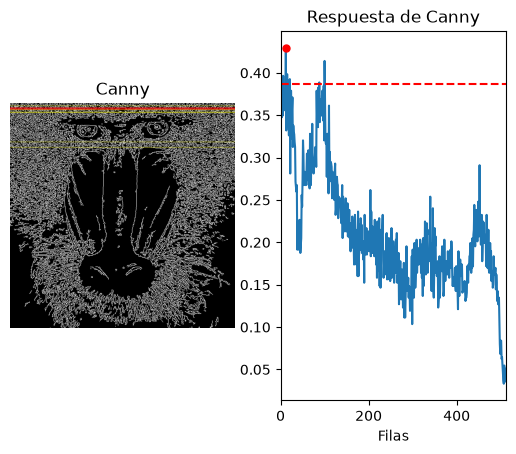

In [7]:
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(draw_threshold(canny_rgb, max_idx, max90_idx, 0.7)) 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")

plt.plot(rows)
plt.plot(max_idx, rows[max_idx], 'o', markersize=5, color='red')
plt.axhline(y=0.9 * rows[max_idx], linestyle='--', color='red')
plt.xlim([0, canny.shape[1]])

### Tarea 2 - Comparativa entre Canny y Sobel umbralizado

Aplicar umbralizado a la imagen de Sobel convertida a 8 bits, y comparar el conteo de filas y columnas (igual que el realizado en la [tarea 1](#tarea-1---bordes-en-canny)) a la imagen resultante de Canny.

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [9]:
def row_counts(image):
    row_counts = cv2.reduce(image, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).reshape(-1)
    return row_counts / (255 * image.shape[1])

In [10]:
def col_counts(image):
    col_counts = cv2.reduce(image, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0]
    return col_counts / (255 * image.shape[0])

In [11]:
def find_max_idx(rows):
    return np.argmax(rows)

def find_max90_idx(rows, max_idx):
    if rows[max_idx] == 0:
        return np.array([], dtype=int)
    return np.where(rows >= 0.9 * rows[max_idx])[0]

In [12]:
def draw_threshold_row(image, max_idx, threshold_idx, alpha=0.5):
    overlay = image.copy()
    for idx in threshold_idx:
        cv2.line(overlay, (0, idx), (image.shape[1], idx), (255, 255, 0), 1)
    cv2.line(overlay, (0, max_idx), (image.shape[1], max_idx), (255, 0, 0), 4)

    return cv2.addWeighted(overlay, alpha, image, 1-alpha, 0)
    
def draw_threshold_col(image, max_idx, threshold_idx, alpha=0.5):
    overlay = image.copy()
    for idx in threshold_idx:
        cv2.line(overlay, (idx, 0), (idx, image.shape[0]), (255, 255, 0), 1)
    cv2.line(overlay, (max_idx, 0), (max_idx, image.shape[0]), (255, 0, 0), 4)

    return cv2.addWeighted(overlay, alpha, image, 1-alpha, 0)

In [13]:
img = cv2.imread('exercises/mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

canny = cv2.Canny(gris, 100, 200)
sobel = cv2.add(
            cv2.Sobel(ggris, cv2.CV_64F, 1, 0), 
            cv2.Sobel(ggris, cv2.CV_64F, 0, 1)
            )

sobel8 = cv2.convertScaleAbs(sobel)

In [14]:
threshold_stats = []

for threshold in range(0, 256):
    threshold_image_rows = row_counts(cv2.threshold(sobel8, threshold, 255, cv2.THRESH_BINARY)[1])
    threshold_stats.append(len(find_max90_idx(threshold_image_rows, find_max_idx(threshold_image_rows))))

Text(153, 14, '(150, 4)')

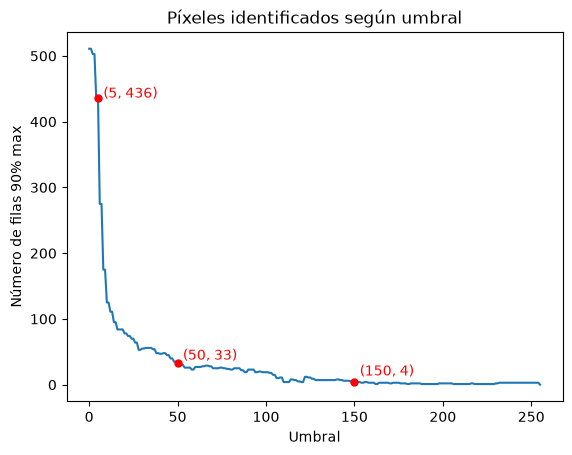

In [15]:
plt.title('Píxeles identificados según umbral')
plt.xlabel('Umbral')
plt.ylabel('Número de filas 90% max')
plt.plot(threshold_stats)

plt.plot(5, threshold_stats[5], 'o', markersize=5, color='red')
plt.annotate(f'(5, {threshold_stats[5]})', xy=(5, threshold_stats[5]), xytext=(8, threshold_stats[5] + 0.5), color='red')
plt.plot(50, threshold_stats[50], 'o', markersize=5, color='red')
plt.annotate(f'(50, {threshold_stats[50]})', xy=(5, threshold_stats[50]), xytext=(53, threshold_stats[50] + 5), color='red')
plt.plot(150, threshold_stats[150], 'o', markersize=5, color='red')
plt.annotate(f'(150, {threshold_stats[150]})', xy=(5, threshold_stats[150]), xytext=(153, threshold_stats[150] + 10), color='red')

In [16]:
canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
rows_canny_rgb = row_counts(canny_rgb)
max_idx_canny = find_max_idx(rows_canny_rgb)
max90_idx_canny = find_max90_idx(rows_canny_rgb, max_idx_canny)


sobel5_rgb = cv2.cvtColor(cv2.threshold(sobel8, 5, 255, cv2.THRESH_BINARY)[1], cv2.COLOR_GRAY2RGB)
rows_sobel5_rgb = row_counts(sobel5_rgb)
max_idx_sobel5 = find_max_idx(rows_sobel5_rgb)
max90_idx_sobel5 = find_max90_idx(rows_sobel5_rgb, max_idx_sobel5)

sobel50_rgb = cv2.cvtColor(cv2.threshold(sobel8, 50, 255, cv2.THRESH_BINARY)[1], cv2.COLOR_GRAY2RGB)
rows_sobel50_rgb = row_counts(sobel50_rgb)
max_idx_sobel50 = find_max_idx(rows_sobel50_rgb)
max90_idx_sobel50 = find_max90_idx(rows_sobel50_rgb, max_idx_sobel50)

sobel150_rgb = cv2.cvtColor(cv2.threshold(sobel8, 150, 255, cv2.THRESH_BINARY)[1], cv2.COLOR_GRAY2RGB)
rows_sobel150_rgb = row_counts(sobel150_rgb)
max_idx_sobel150 = find_max_idx(rows_sobel150_rgb)
max90_idx_sobel150 = find_max90_idx(rows_sobel150_rgb, max_idx_sobel150)

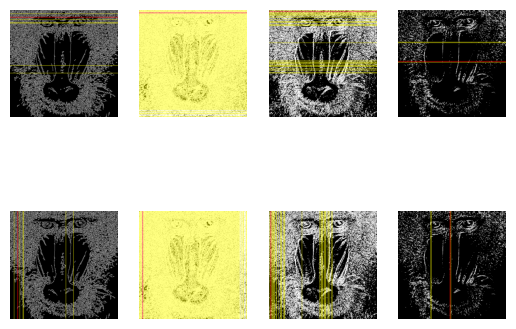

In [17]:
fig = plt.figure()
gs0 = gridspec.GridSpec(2, 4, figure=fig)

canny_subplot_row = fig.add_subplot(gs0[0, 0])
canny_subplot_col = fig.add_subplot(gs0[1, 0])

sobel5_subplot_row = fig.add_subplot(gs0[0, 1])
sobel50_subplot_row = fig.add_subplot(gs0[0, 2])
sobel150_subplot_row = fig.add_subplot(gs0[0, 3])

sobel5_subplot_col = fig.add_subplot(gs0[1, 1])
sobel50_subplot_col = fig.add_subplot(gs0[1, 2])
sobel150_subplot_col = fig.add_subplot(gs0[1, 3])

canny_subplot_row.axis('off')
canny_subplot_row.imshow(draw_threshold_row(canny_rgb, max_idx_canny, max90_idx_canny), cmap='gray')

canny_subplot_col.axis('off')
canny_subplot_col.imshow(draw_threshold_col(canny_rgb, max_idx_canny, max90_idx_canny), cmap='gray')

sobel5_subplot_row.axis('off')
sobel5_subplot_row.imshow(draw_threshold_row(sobel5_rgb, max_idx_sobel5, max90_idx_sobel5), cmap='gray')

sobel50_subplot_row.axis('off')
sobel50_subplot_row.imshow(draw_threshold_row(sobel50_rgb, max_idx_sobel50, max90_idx_sobel50), cmap='gray')

sobel150_subplot_row.axis('off')
sobel150_subplot_row.imshow(draw_threshold_row(sobel150_rgb, max_idx_sobel150, max90_idx_sobel150), cmap='gray')

sobel5_subplot_col.axis('off')
sobel5_subplot_col.imshow(draw_threshold_col(sobel5_rgb, max_idx_sobel5, max90_idx_sobel5), cmap='gray')

sobel50_subplot_col.axis('off')
sobel50_subplot_col.imshow(draw_threshold_col(sobel50_rgb, max_idx_sobel50, max90_idx_sobel50), cmap='gray')

sobel150_subplot_col.axis('off')
sobel150_subplot_col.imshow(draw_threshold_col(sobel150_rgb, max_idx_sobel150, max90_idx_sobel150), cmap='gray')

### Tarea 3 - Demostraciones con procesamiento de imagen

In [ ]:
city_gif = cv2.VideoCapture('./exercises/city-gif.gif')
vid = cv2.VideoCapture(0)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

backgroundSubtractor = cv2.createBackgroundSubtractorMOG2(history=10000, varThreshold=160, detectShadows=False)

width = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter('./exercises/tarea3_1.mp4', fourcc, 20.0, (3 * width, height))

ret, frame = vid.read()

while(True):
    ret, frame = vid.read()
    city_ret, city_frame = city_gif.read()

    if not city_ret:
        city_gif.set(cv2.CAP_PROP_POS_FRAMES, 0)
        city_ret, city_frame = city_gif.read()

    if ret:
        resized_img = cv2.resize(city_frame, (width, height), interpolation=cv2.INTER_CUBIC)

        objects = backgroundSubtractor.apply(frame)
        background = cv2.bitwise_not(objects)

        objects_mask = cv2.bitwise_and(frame, frame, mask=objects)
        background_mask = cv2.bitwise_and(resized_img, resized_img, mask=background)
        result = cv2.add(objects_mask, background_mask)

        collage = np.hstack((frame, objects_mask, result))
        
        out.write(collage)
        cv2.imshow('Tarea3', cv2.resize(collage, (int(width*1.5),int(height/2)),cv2.INTER_NEAREST))
   
    if cv2.waitKey(20) == 27:
        break

vid.release()
out.release()

cv2.destroyAllWindows()